# Task 1
### Dat Cleaning and Data Visualization

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ecommerce_sales_data = pd.read_csv("data/messy_ecommerce_sales_data.csv")

In [96]:
ecommerce_sales_data.shape

(103, 11)

In [97]:
ecommerce_sales_data.head(20)

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Delivered,114.000
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Delivered,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Delivered,1169.600
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Delivered,552.510
5,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,3,122.06,Cash on Delivery,Delivered,366.180
6,106,Customer_106,ORD-25885,2/2/2025,Blender,Home,NaN,978.63,Bank Transfer,Delivered,NaN
7,107,Customer_107,ORD-89122,1/3/2025,Biography,Books,5,587.68,PayPal,Delivered,2938.400
8,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,Cash on Delivery,Delivered,600.290
9,109,Customer_109,ORD-18512,5/3/2025,Tennis Racket,Sports,5,168.34,Credit Card,Delivered,841.700


##### 👉 Drop Duplicate Records

In [98]:
ecommerce_sales_data[ecommerce_sales_data.duplicated()]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [99]:
ecommerce_sales_data = ecommerce_sales_data.drop_duplicates()

---

#### 👉 Handling all the Feature of Data Set
1. strip()
2. delete Customer_Name Fatures -> since it use customere id only

In [100]:

ecommerce_sales_data.columns = [
    i.strip() for i in ecommerce_sales_data.columns.tolist()
]
del ecommerce_sales_data["Customer_Name"]

---

##### 👉 Handling "Order_ID" Feature
1. Removing Prefix "ORD-" 
2. Converting the data to "Int64"

In [101]:
## For checking not matched Patter in order id
print(
    "Not Matched Pattern (Order_ID):",
    (~ecommerce_sales_data["Order_ID"].astype(str).str.match("^ORD-\d+$")).sum(),
)
ecommerce_sales_data["Order_ID"]=pd.to_numeric(ecommerce_sales_data["Order_ID"].str.replace("ORD-", "").astype("Int64"))

Not Matched Pattern (Order_ID): 0


---

##### 👉 Handling "Order_Date" Feature
1. Changing differnt type of data wording to proper data string
2. Converting the Order_Date featues to data_time() formate

In [102]:
ecommerce_sales_data[~(ecommerce_sales_data['Order_Date'].str.match("(\d{1,2})/(\d{1,2})/(\d{4})"))]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
14,114,77417,Jan 5 2023,Smartphone,Electronics,2,413.13,Cash on Delivery,Delivered,826.26
92,192,35144,abc,Jacket,Clothing,4a,203.63,Credit Card,Returned,NaN


In [103]:
ecommerce_sales_data.loc[14, "Order_Date"] = "1/5/2023"

In [104]:
ecommerce_sales_data[
    ~(ecommerce_sales_data["Order_Date"].str.match("(\d{1,2})/(\d{1,2})/(\d{4})"))
]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
92,192,35144,abc,Jacket,Clothing,4a,203.63,Credit Card,Returned,NaN


In [105]:
ecommerce_sales_data.Order_Date = pd.to_datetime(ecommerce_sales_data.Order_Date, errors="coerce")

In [106]:
ecommerce_sales_data.Order_Date.isna().sum()

np.int64(1)

---

##### 👉 Handling "Product" Feature
1. strip()
2. upper()


In [107]:
ecommerce_sales_data.Product = ecommerce_sales_data.Product.str.strip().str.upper()

In [108]:
ecommerce_sales_data.duplicated().sum()

np.int64(0)

In [109]:
ecommerce_sales_data.Product.unique()

<StringArray>
[      'BLENDER',    'SMARTPHONE', 'TENNIS RACKET',       'SCIENCE',
     'BIOGRAPHY',    'BASKETBALL',        'COMICS',         'SHOES',
       'FICTION',     'MICROWAVE',      'YOGA MAT',        'VACUUM',
          'LAMP',       'T-SHIRT',    'SMARTWATCH',    'HEADPHONES',
      'FOOTBALL',        'LAPTOP',        'JACKET',         'JEANS']
Length: 20, dtype: str

---

##### 👉 Handling  "Category" Feature
1. strip()
2. upper()
3. replace() - ELECTRONIC -> ELECTRONICS

In [110]:
ecommerce_sales_data.Category = ecommerce_sales_data.Category.str.strip().str.upper()

In [111]:
ecommerce_sales_data.duplicated().sum()

np.int64(0)

In [112]:
ecommerce_sales_data.Category.unique()

<StringArray>
['HOME', 'ELECTRONICS', 'SPORTS', 'BOOKS', 'CLOTHING', 'ELECTRONIC', nan]
Length: 7, dtype: str

In [113]:
ecommerce_sales_data["Category"] = ecommerce_sales_data["Category"].replace(
    "ELECTRONIC", "ELECTRONICS"
)

#### 👉 Handling "Category" Feature - 2
1. Remove rows where Product or Category is missing.
2. Group the data by Product.
3. For each product, find the most common Category using x.mode()[0].
4. Convert the result into a dictionary (Product → Category).
5. Create a mask to identify rows where Category is missing.
6. Select the missing Category rows using the mask.
7. Use the Product value to look up its category from the dictionary using map().
8. Fill the missing Category values with the mapped category.

In [114]:
ecommerce_sales_data.Category.isna().sum()

np.int64(8)

In [115]:
ecommerce_sales_data[ecommerce_sales_data.Category.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
33,133,68182,2024-12-05,BIOGRAPHY,NaN,5,343.24,Credit Card,Delivered,1716.20
36,136,20985,2025-06-12,HEADPHONES,NaN,1,696.71,Credit Card,Delivered,696.71
80,180,86629,2025-03-26,LAPTOP,NaN,2,418.38,Credit Card,Processing,836.76
81,181,54481,2024-12-29,SMARTPHONE,NaN,1,266.48,Cash on Delivery,Cancelled,266.48
82,182,79672,2025-08-03,SHOES,NaN,4,538.35,PayPal,Processing,2153.40
84,184,67799,2025-02-15,JEANS,NaN,4,101.19,Bank Transfer,Processing,404.76
93,193,42475,2025-06-06,BASKETBALL,NaN,NaN,522.02,PayPal,Shipped,NaN
98,198,14608,2025-07-27,VACUUM,NaN,2,497.01,Cash on Delivery,Shipped,994.02


In [116]:
pd.crosstab(index=ecommerce_sales_data.Product, columns=ecommerce_sales_data.Category, margins=True)

Category,BOOKS,CLOTHING,ELECTRONICS,HOME,SPORTS,All
Product,,,,,,
BASKETBALL,0,0,2,0,5,7
BIOGRAPHY,4,0,0,0,0,4
BLENDER,0,0,1,7,0,8
COMICS,7,0,0,0,0,7
FICTION,5,0,0,0,0,5
FOOTBALL,0,0,0,0,2,2
HEADPHONES,0,0,2,0,0,2
JACKET,0,3,0,0,0,3
JEANS,0,2,0,0,0,2


In [117]:
product_category_map = (
    ecommerce_sales_data.dropna(subset=["Product", "Category"])
    .groupby("Product")["Category"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

mask = ecommerce_sales_data.Category.isna()

ecommerce_sales_data.loc[mask, "Category"] = ecommerce_sales_data.loc[
    mask, "Product"
].map(product_category_map)

In [118]:
ecommerce_sales_data.Category.isna().sum()

np.int64(0)

In [119]:
ecommerce_sales_data.isna().sum()

ID                 0
Order_ID           0
Order_Date         1
Product            0
Category           0
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

---

##### 👉 Handling "Payment_Method" Featues 

In [120]:
ecommerce_sales_data[ecommerce_sales_data.Payment_Method.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [121]:
ecommerce_sales_data.Payment_Method.info()

<class 'pandas.Series'>
RangeIndex: 103 entries, 0 to 102
Series name: Payment_Method
Non-Null Count  Dtype
--------------  -----
103 non-null    str  
dtypes: str(1)
memory usage: 956.0 bytes


In [122]:
ecommerce_sales_data.Payment_Method.unique()

<StringArray>
['Cash on Delivery', 'PayPal', 'Bank Transfer', 'Credit Card']
Length: 4, dtype: str

---

##### 👉 Handling "Stauts" Features  

In [123]:
ecommerce_sales_data[ecommerce_sales_data.Status.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [124]:
ecommerce_sales_data.Status.info()

<class 'pandas.Series'>
RangeIndex: 103 entries, 0 to 102
Series name: Status
Non-Null Count  Dtype
--------------  -----
103 non-null    str  
dtypes: str(1)
memory usage: 956.0 bytes


In [125]:
ecommerce_sales_data.Status.unique()

<StringArray>
['Delivered', 'Returned', 'Processing', 'Cancelled', 'Shipped']
Length: 5, dtype: str

---

#### 👉 Handling Quanity Featues - 1
1. .match() - for checking the invalid data using regex
2. .replace() - for changing those invalid data using regex
3. .abs() - to handle negative data

In [126]:
ecommerce_sales_data.Quantity.isna().sum()

np.int64(5)

In [127]:
ecommerce_sales_data[ecommerce_sales_data.Quantity.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
6,106,25885,2025-02-02,BLENDER,HOME,NaN,978.63,Bank Transfer,Delivered,NaN
64,164,23010,2025-02-09,TENNIS RACKET,SPORTS,NaN,587.64,Credit Card,Returned,NaN
67,167,30329,2025-08-07,BASKETBALL,SPORTS,NaN,593.93,Cash on Delivery,Processing,NaN
93,193,42475,2025-06-06,BASKETBALL,SPORTS,NaN,522.02,PayPal,Shipped,NaN
96,196,78384,2024-12-23,VACUUM,HOME,NaN,abd,PayPal,Delivered,NaN


In [128]:
ecommerce_sales_data.Quantity.info()

<class 'pandas.Series'>
RangeIndex: 103 entries, 0 to 102
Series name: Quantity
Non-Null Count  Dtype
--------------  -----
98 non-null     str  
dtypes: str(1)
memory usage: 956.0 bytes


In [129]:
ecommerce_sales_data[~ecommerce_sales_data.Quantity.str.match("(^\d+$)")]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
6,106,25885,2025-02-02,BLENDER,HOME,NaN,978.63,Bank Transfer,Delivered,NaN
17,117,72751,2025-02-12,BLENDER,ELECTRONICS,-2,10000,Cash on Delivery,Delivered,-20000.00
34,134,16585,2025-10-04,T-SHIRT,CLOTHING,-5,591.53,PayPal,Delivered,-2957.65
64,164,23010,2025-02-09,TENNIS RACKET,SPORTS,NaN,587.64,Credit Card,Returned,NaN
67,167,30329,2025-08-07,BASKETBALL,SPORTS,NaN,593.93,Cash on Delivery,Processing,NaN
92,192,35144,NaT,JACKET,CLOTHING,4a,203.63,Credit Card,Returned,NaN
93,193,42475,2025-06-06,BASKETBALL,SPORTS,NaN,522.02,PayPal,Shipped,NaN
96,196,78384,2024-12-23,VACUUM,HOME,NaN,abd,PayPal,Delivered,NaN


In [130]:
ecommerce_sales_data.Quantity = pd.to_numeric(
    ecommerce_sales_data.Quantity.str.replace("([A-Za-z]+)", "", regex=True),
    errors="coerce",
).astype("Int64").abs()

In [131]:
ecommerce_sales_data.Quantity.info()

<class 'pandas.Series'>
RangeIndex: 103 entries, 0 to 102
Series name: Quantity
Non-Null Count  Dtype
--------------  -----
98 non-null     Int64
dtypes: Int64(1)
memory usage: 1.0 KB


In [132]:
ecommerce_sales_data[ecommerce_sales_data.Quantity <= 0]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [133]:
ecommerce_sales_data.Quantity.isna().sum()

np.int64(5)

In [134]:
ecommerce_sales_data[ecommerce_sales_data.Quantity.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
6,106,25885,2025-02-02,BLENDER,HOME,<NA>,978.63,Bank Transfer,Delivered,NaN
64,164,23010,2025-02-09,TENNIS RACKET,SPORTS,<NA>,587.64,Credit Card,Returned,NaN
67,167,30329,2025-08-07,BASKETBALL,SPORTS,<NA>,593.93,Cash on Delivery,Processing,NaN
93,193,42475,2025-06-06,BASKETBALL,SPORTS,<NA>,522.02,PayPal,Shipped,NaN
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,abd,PayPal,Delivered,NaN


---

#### 👉 Handling Price Featues
1. .match() - check invalid data using regex
2. .replace() - to change the invalid data to correct format using regex
3. changing other invalid data manual assignmne (for only one record)
4. once again verify and convert the data to float using .to_numberic

In [135]:
ecommerce_sales_data.Price.isna().sum()

np.int64(5)

In [136]:
ecommerce_sales_data.Price.info()

<class 'pandas.Series'>
RangeIndex: 103 entries, 0 to 102
Series name: Price
Non-Null Count  Dtype
--------------  -----
98 non-null     str  
dtypes: str(1)
memory usage: 956.0 bytes


In [137]:
ecommerce_sales_data[~ecommerce_sales_data.Price.str.match("(^(\d+(\.\d+)?|\.\d+)$)")]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,35783,2025-07-05,SMARTPHONE,ELECTRONICS,2,abd,PayPal,Delivered,NaN
10,110,61020,2025-09-26,BASKETBALL,SPORTS,5,four hundred,Cash on Delivery,Delivered,NaN
16,116,63660,2025-10-30,MICROWAVE,HOME,4,NaN,Cash on Delivery,Delivered,NaN
20,120,14659,2025-06-13,YOGA MAT,ELECTRONICS,5,300$,Credit Card,Delivered,NaN
24,124,46136,2025-05-31,COMICS,BOOKS,5,NaN,PayPal,Delivered,NaN
30,130,34007,2025-08-15,TENNIS RACKET,SPORTS,2,NaN,Bank Transfer,Delivered,NaN
37,137,91254,2025-02-23,VACUUM,HOME,3,-100,Cash on Delivery,Delivered,-300.0
56,156,34679,2024-11-28,JEANS,CLOTHING,2,NaN,Bank Transfer,Shipped,NaN
83,183,20916,2025-03-10,SHOES,CLOTHING,5,NaN,Cash on Delivery,Returned,NaN
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,abd,PayPal,Delivered,NaN


In [138]:
ecommerce_sales_data.Price = ecommerce_sales_data.Price.str.replace(
    "[^\d.]", "", regex=True
)

In [139]:
ecommerce_sales_data.Price

0          38
1            
2      389.05
3      233.92
4      552.51
        ...  
98     497.01
99     372.28
100    111.36
101    645.26
102    705.42
Name: Price, Length: 103, dtype: str

In [140]:
# ecommerce_sales_data.loc[10, "Price"] = "400"
ecommerce_sales_data.loc[ecommerce_sales_data["Price"] == "four hundred", "Price"] = "400"

In [141]:
ecommerce_sales_data[~ecommerce_sales_data.Price.str.match("(^(\d+(\.\d+)?|\.\d+)$)")]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,35783,2025-07-05,SMARTPHONE,ELECTRONICS,2,,PayPal,Delivered,NaN
10,110,61020,2025-09-26,BASKETBALL,SPORTS,5,,Cash on Delivery,Delivered,NaN
16,116,63660,2025-10-30,MICROWAVE,HOME,4,NaN,Cash on Delivery,Delivered,NaN
24,124,46136,2025-05-31,COMICS,BOOKS,5,NaN,PayPal,Delivered,NaN
30,130,34007,2025-08-15,TENNIS RACKET,SPORTS,2,NaN,Bank Transfer,Delivered,NaN
56,156,34679,2024-11-28,JEANS,CLOTHING,2,NaN,Bank Transfer,Shipped,NaN
83,183,20916,2025-03-10,SHOES,CLOTHING,5,NaN,Cash on Delivery,Returned,NaN
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,,PayPal,Delivered,NaN


In [142]:
ecommerce_sales_data.Price = pd.to_numeric(ecommerce_sales_data.Price, errors="coerce").abs()

In [143]:
ecommerce_sales_data.Price.isna().sum()

np.int64(8)

In [144]:
ecommerce_sales_data[ecommerce_sales_data.Price.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,35783,2025-07-05,SMARTPHONE,ELECTRONICS,2,NaN,PayPal,Delivered,NaN
10,110,61020,2025-09-26,BASKETBALL,SPORTS,5,NaN,Cash on Delivery,Delivered,NaN
16,116,63660,2025-10-30,MICROWAVE,HOME,4,NaN,Cash on Delivery,Delivered,NaN
24,124,46136,2025-05-31,COMICS,BOOKS,5,NaN,PayPal,Delivered,NaN
30,130,34007,2025-08-15,TENNIS RACKET,SPORTS,2,NaN,Bank Transfer,Delivered,NaN
56,156,34679,2024-11-28,JEANS,CLOTHING,2,NaN,Bank Transfer,Shipped,NaN
83,183,20916,2025-03-10,SHOES,CLOTHING,5,NaN,Cash on Delivery,Returned,NaN
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,NaN,PayPal,Delivered,NaN


In [145]:
pd.to_numeric(ecommerce_sales_data["Price"], errors="coerce").isna().sum()

np.int64(8)

---

#### 👉 Handling Price Feature - 2
1. Phase 1
    1. Group data by Product + Quantity and calculate average Price.
    2. Convert the result into a dictionary for lookup.
    3. Find rows where Price is missing.
    4. Match Product + Quantity with the dictionary and fill missing Prices.
2. Phase 2
    1. Filter rows where Quantity = 1.
    2. Group by Product and calculate the average Price.
    3. Convert this into a Product → Unit Price dictionary.
    4. Find rows where Price is still missing.
    5. For each missing row, look up the product’s unit price from the dictionary.
    6. Fill the missing Price values with the matched unit price (if Quantity exists).
3. Phase 3
    1. Find rows where Price is still missing.
    2. Remove rows with missing Price or Quantity.
    3. Sort data by Quantity.
    4. For each Product, select the row with the minimum Quantity.
    5. Calculate unit price = Price ÷ Quantity.
    6. Create a Product → Unit Price dictionary.
    7. Fill missing Price values using the product’s unit price (if Quantity exists).



In [146]:
pd.pivot_table(
    data=ecommerce_sales_data,
    index="Product",
    columns="Quantity",
    values="Price",
)

Quantity,1,2,3,4,5
Product,,,,,
BASKETBALL,582.130000,705.420,NaN,480.600000,NaN
BIOGRAPHY,552.510000,141.490,NaN,NaN,582.793333
BLENDER,160.160000,5077.880,38.000,NaN,499.313333
COMICS,NaN,755.230,NaN,765.690000,713.450000
FICTION,411.810000,838.930,546.040,588.980000,NaN
FOOTBALL,NaN,730.920,NaN,NaN,849.070000
HEADPHONES,306.476667,NaN,NaN,NaN,NaN
JACKET,NaN,NaN,NaN,358.293333,NaN
JEANS,NaN,NaN,NaN,101.190000,741.630000


In [147]:
price_lookup = ecommerce_sales_data.groupby(["Product", "Quantity"])["Price"].mean()
price_dict = price_lookup.to_dict()
mask = ecommerce_sales_data.Price.isna()
ecommerce_sales_data.loc[mask, "Price"] = (ecommerce_sales_data.loc[mask].set_index(["Product", "Quantity"]).index.map(price_dict))

In [148]:
ecommerce_sales_data[ecommerce_sales_data.Price.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
10,110,61020,2025-09-26,BASKETBALL,SPORTS,5,NaN,Cash on Delivery,Delivered,NaN
30,130,34007,2025-08-15,TENNIS RACKET,SPORTS,2,NaN,Bank Transfer,Delivered,NaN
56,156,34679,2024-11-28,JEANS,CLOTHING,2,NaN,Bank Transfer,Shipped,NaN
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,NaN,PayPal,Delivered,NaN


In [149]:
unit_price_dict = (
    ecommerce_sales_data[ecommerce_sales_data["Quantity"] == 1]
    .groupby("Product")["Price"]
    .mean()
    .to_dict()
)

remaining_mask = ecommerce_sales_data["Price"].isna()

ecommerce_sales_data.loc[remaining_mask, "Price"] = ecommerce_sales_data.loc[
    remaining_mask
].apply(
    lambda row: (
        unit_price_dict.get(row["Product"], np.nan)
        if pd.notna(row["Quantity"])
        else np.nan
    ),
    axis=1,
)

In [150]:
ecommerce_sales_data[ecommerce_sales_data.Price.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
56,156,34679,2024-11-28,JEANS,CLOTHING,2,NaN,Bank Transfer,Shipped,NaN
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,NaN,PayPal,Delivered,NaN


In [151]:
remaining_mask = ecommerce_sales_data["Price"].isna()

min_qty_unit_price = (
    ecommerce_sales_data.dropna(subset=["Price", "Quantity"])
    .sort_values("Quantity")
    .groupby("Product")
    .first()
)

unit_price_dict = (
    min_qty_unit_price["Price"] / min_qty_unit_price["Quantity"]
).to_dict()


ecommerce_sales_data.loc[remaining_mask, "Price"] = ecommerce_sales_data.loc[
    remaining_mask
].apply(
    lambda row: (
        unit_price_dict.get(row["Product"], np.nan)
        if pd.notna(row["Quantity"])
        else np.nan
    ),
    axis=1,
)

In [152]:
ecommerce_sales_data[ecommerce_sales_data.Price.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,NaN,PayPal,Delivered,NaN


#### 👉 Handling Quantity Feature - 2
1. Phase - 1
    1. Remove rows with missing Product, Price, or Quantity.
    2. Group data by Product and Price.
    3. Calculate the average Quantity for each Product–Price pair.
    4. Convert this into a lookup dictionary.
    5. Find rows where Quantity is missing.
    6. Match Product + Price with the dictionary.
    7. Fill missing Quantity values using the matched average quantity.
2. Phase - 2
    1. Remove rows with missing Price or Quantity.
    2. Sort data by Quantity and select the minimum quantity row for each Product.
    3. Calculate unit price = Price ÷ Quantity.
    4. Create a Product → Unit Price dictionary.
    5. Find rows where Quantity is missing.
    6. Estimate Quantity = Price ÷ Unit Price.
    7. Fill missing Quantity values with the estimated quantity.


In [153]:
quantity_lookup = (
    ecommerce_sales_data.dropna(subset=["Product", "Price", "Quantity"])
    .groupby(["Product", "Price"])["Quantity"]
    .mean()
    .to_dict()
)

qty_mask = ecommerce_sales_data["Quantity"].isna()

ecommerce_sales_data.loc[qty_mask, "Quantity"] = (
    ecommerce_sales_data.loc[qty_mask]
    .set_index(["Product", "Price"])
    .index.map(quantity_lookup)
)

In [154]:
unit_price_dict = (
    ecommerce_sales_data.dropna(subset=["Price", "Quantity"])
    .sort_values("Quantity")
    .groupby("Product")
    .first()
)

unit_price_dict = (unit_price_dict["Price"] / unit_price_dict["Quantity"]).to_dict()

qty_mask = ecommerce_sales_data["Quantity"].isna()

ecommerce_sales_data.loc[qty_mask, "Quantity"] = ecommerce_sales_data.loc[
    qty_mask
].apply(
    lambda row: (
        round(row["Price"] / unit_price_dict.get(row["Product"], np.nan))
        if pd.notna(row["Price"])
        else np.nan
    ),
    axis=1,
)

In [155]:
ecommerce_sales_data.Quantity.isna().sum()

np.int64(1)

In [156]:
ecommerce_sales_data[ecommerce_sales_data.Quantity.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,NaN,PayPal,Delivered,NaN


#### 👉 Handling "Total" Feature
1. converting to float
2. Phase - 2
    1. Find rows where Total is missing.
    2. Select only the rows with missing Total.
    3. Calculate Total = Quantity × Price for each row using apply().
    4. Fill the missing Total values with the calculated result.



In [157]:
ecommerce_sales_data[ecommerce_sales_data.isna().any(axis=1)]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,35783,2025-07-05,SMARTPHONE,ELECTRONICS,2,547.2550,PayPal,Delivered,NaN
6,106,25885,2025-02-02,BLENDER,HOME,6,978.6300,Bank Transfer,Delivered,NaN
10,110,61020,2025-09-26,BASKETBALL,SPORTS,5,582.1300,Cash on Delivery,Delivered,NaN
16,116,63660,2025-10-30,MICROWAVE,HOME,4,187.4800,Cash on Delivery,Delivered,NaN
20,120,14659,2025-06-13,YOGA MAT,ELECTRONICS,5,300.0000,Credit Card,Delivered,NaN
24,124,46136,2025-05-31,COMICS,BOOKS,5,713.4500,PayPal,Delivered,NaN
30,130,34007,2025-08-15,TENNIS RACKET,SPORTS,2,525.0150,Bank Transfer,Delivered,NaN
56,156,34679,2024-11-28,JEANS,CLOTHING,2,25.2975,Bank Transfer,Shipped,NaN
64,164,23010,2025-02-09,TENNIS RACKET,SPORTS,2,587.6400,Credit Card,Returned,NaN
67,167,30329,2025-08-07,BASKETBALL,SPORTS,1,593.9300,Cash on Delivery,Processing,NaN


In [158]:
ecommerce_sales_data.Total.info()

<class 'pandas.Series'>
RangeIndex: 103 entries, 0 to 102
Series name: Total
Non-Null Count  Dtype  
--------------  -----  
89 non-null     float64
dtypes: float64(1)
memory usage: 956.0 bytes


In [159]:
ecommerce_sales_data[ecommerce_sales_data.Total.isna()]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
1,101,35783,2025-07-05,SMARTPHONE,ELECTRONICS,2,547.2550,PayPal,Delivered,NaN
6,106,25885,2025-02-02,BLENDER,HOME,6,978.6300,Bank Transfer,Delivered,NaN
10,110,61020,2025-09-26,BASKETBALL,SPORTS,5,582.1300,Cash on Delivery,Delivered,NaN
16,116,63660,2025-10-30,MICROWAVE,HOME,4,187.4800,Cash on Delivery,Delivered,NaN
20,120,14659,2025-06-13,YOGA MAT,ELECTRONICS,5,300.0000,Credit Card,Delivered,NaN
24,124,46136,2025-05-31,COMICS,BOOKS,5,713.4500,PayPal,Delivered,NaN
30,130,34007,2025-08-15,TENNIS RACKET,SPORTS,2,525.0150,Bank Transfer,Delivered,NaN
56,156,34679,2024-11-28,JEANS,CLOTHING,2,25.2975,Bank Transfer,Shipped,NaN
64,164,23010,2025-02-09,TENNIS RACKET,SPORTS,2,587.6400,Credit Card,Returned,NaN
67,167,30329,2025-08-07,BASKETBALL,SPORTS,1,593.9300,Cash on Delivery,Processing,NaN


In [160]:
ecommerce_sales_data["Total"] = ecommerce_sales_data["Total"].astype("Float64").abs()

In [161]:
tot_mask = ecommerce_sales_data["Total"].isna()
ecommerce_sales_data.loc[tot_mask, "Total"] = (ecommerce_sales_data.loc[tot_mask].apply(lambda row: row["Quantity"] * row["Price"], axis=1))

#### 👉 Dropping the Other NaN Records

In [162]:
ecommerce_sales_data[ecommerce_sales_data.isna().any(axis=1)]

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
92,192,35144,NaT,JACKET,CLOTHING,4,203.63,Credit Card,Returned,814.52
96,196,78384,2024-12-23,VACUUM,HOME,<NA>,NaN,PayPal,Delivered,<NA>


In [163]:
ecommerce_sales_data = ecommerce_sales_data.dropna()

In [164]:
ecommerce_sales_data.isna().sum()

ID                0
Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [165]:
ecommerce_sales_data.sort_values(by="Order_Date",ascending=True,  inplace=True)

In [166]:
ecommerce_sales_data

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
63,163,24378,2023-01-05,SMARTWATCH,ELECTRONICS,3,235.26,Cash on Delivery,Shipped,705.78
14,114,77417,2023-01-05,SMARTPHONE,ELECTRONICS,2,413.13,Cash on Delivery,Delivered,826.26
45,145,75314,2023-05-01,LAPTOP,ELECTRONICS,2,860.99,Bank Transfer,Delivered,1721.98
65,165,55695,2024-11-08,SHOES,CLOTHING,2,443.13,Credit Card,Delivered,886.26
28,128,12270,2024-11-10,LAMP,ELECTRONICS,3,898.69,Bank Transfer,Delivered,2696.07
...,...,...,...,...,...,...,...,...,...,...
101,142,69018,2025-10-30,SHOES,CLOTHING,5,645.26,Credit Card,Shipped,3226.3
16,116,63660,2025-10-30,MICROWAVE,HOME,4,187.48,Cash on Delivery,Delivered,749.92
42,142,69018,2025-10-30,SHOES,CLOTHING,5,645.26,Credit Card,Delivered,2258.41
68,168,53430,2025-11-04,BIOGRAPHY,BOOKS,2,141.49,PayPal,Cancelled,282.98


---

## Data Cleaning End - Got Cleaned Data

In [167]:
ecommerce_sales_data.to_csv("data/Cleaned_ecommerce_sales_data.csv")

---

## Different Type of Chart for Data Visualization

In [168]:
delivered_order = ecommerce_sales_data[ecommerce_sales_data.Status == "Delivered"]

In [169]:
delivered_order.head()

,ID,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
14,114,77417,2023-01-05,SMARTPHONE,ELECTRONICS,2,413.13,Cash on Delivery,Delivered,826.26
45,145,75314,2023-05-01,LAPTOP,ELECTRONICS,2,860.99,Bank Transfer,Delivered,1721.98
65,165,55695,2024-11-08,SHOES,CLOTHING,2,443.13,Credit Card,Delivered,886.26
28,128,12270,2024-11-10,LAMP,ELECTRONICS,3,898.69,Bank Transfer,Delivered,2696.07
5,105,22442,2024-11-20,TENNIS RACKET,SPORTS,3,122.06,Cash on Delivery,Delivered,366.18


### 1.Univariate Data

#### 1.1 Histplot()

Text(0, 0.5, 'Frequency')

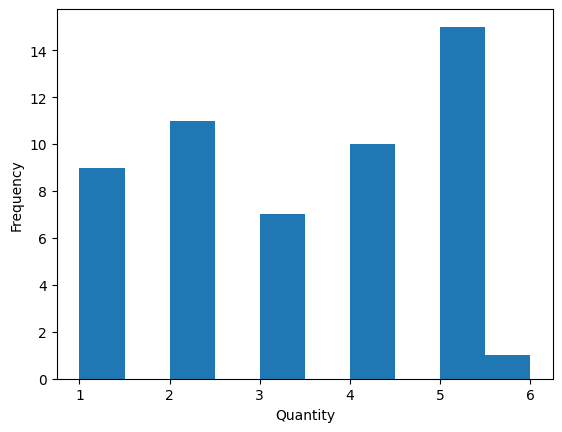

In [170]:
plt.hist(delivered_order.Quantity)
plt.xlabel("Quantity")
plt.ylabel("Frequency")

#### Insights
- Customers buying 5 products together is the most common
- Customers buying 6 products together is relatively low

#### 1.2 Countplot()

Text(0, 0.5, 'Frequency')

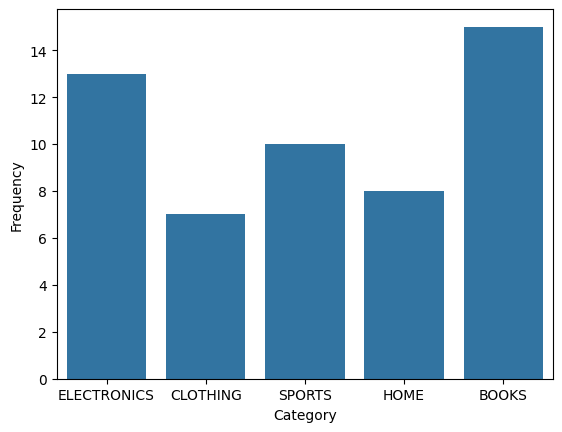

In [171]:
sns.countplot(delivered_order, x="Category")
plt.xlabel("Category")
plt.ylabel("Frequency")

#### Insights
- Electronics and Book have high frequency compared to other
- Clothing have low frequency

#### 1.3 Pie Chart

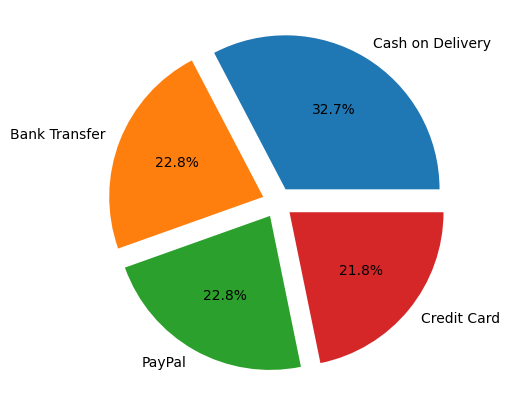

In [172]:
payment_category = ecommerce_sales_data.Payment_Method.value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    x=payment_category,
    labels=[f"{i}" for i in payment_category.index],
    explode=[0.1] * len(payment_category),
    autopct="%1.1f%%",
)
plt.show()

#### Insights
- Cash on Delivery is most used payment method
- Credit Card is lowest usage 
- Digital Payment is most preffered over cash on delivery

### 2. Bivariate Data

#### 2.1 Barplot

<Axes: xlabel='Category', ylabel='Total'>

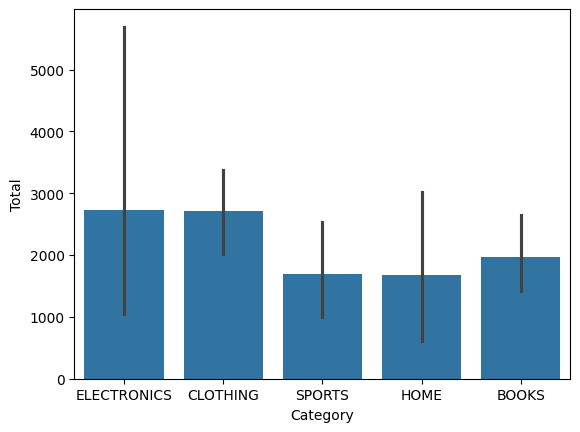

In [173]:
sns.barplot(data=delivered_order, x="Category", y="Total")

#### Insights
- Electronics and Clothing have higher sales
- All other category have moderate sales

#### 2.2 Scatter Plot

<Axes: xlabel='Price', ylabel='Total'>

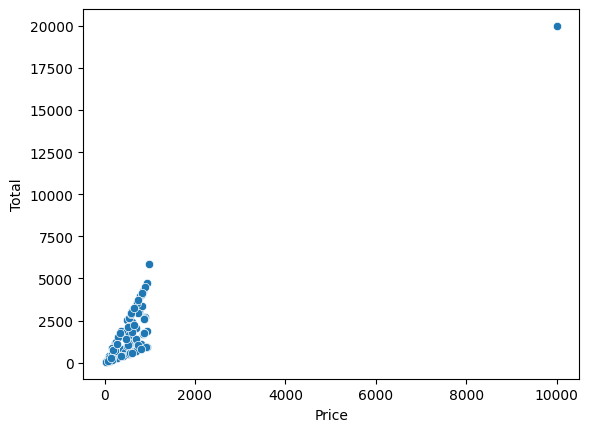

In [174]:
sns.scatterplot(data=ecommerce_sales_data, x="Price", y="Total")

#### Insights
- Price and Total Amount show a positive trend

#### 2.3 Lineplot

<Axes: xlabel='Order_Date', ylabel='Total'>

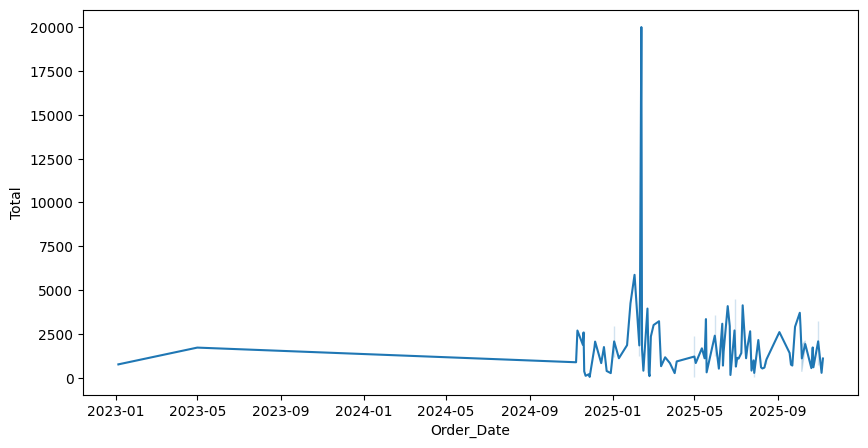

In [175]:
plt.figure(figsize=(10,5))
sns.lineplot(data=ecommerce_sales_data, x="Order_Date", y="Total")

#### Insights
- Total sales fluctuate over the month
- Higher peak in early 2025

### 3. Multivariate Data

#### 3.1 Pariplot

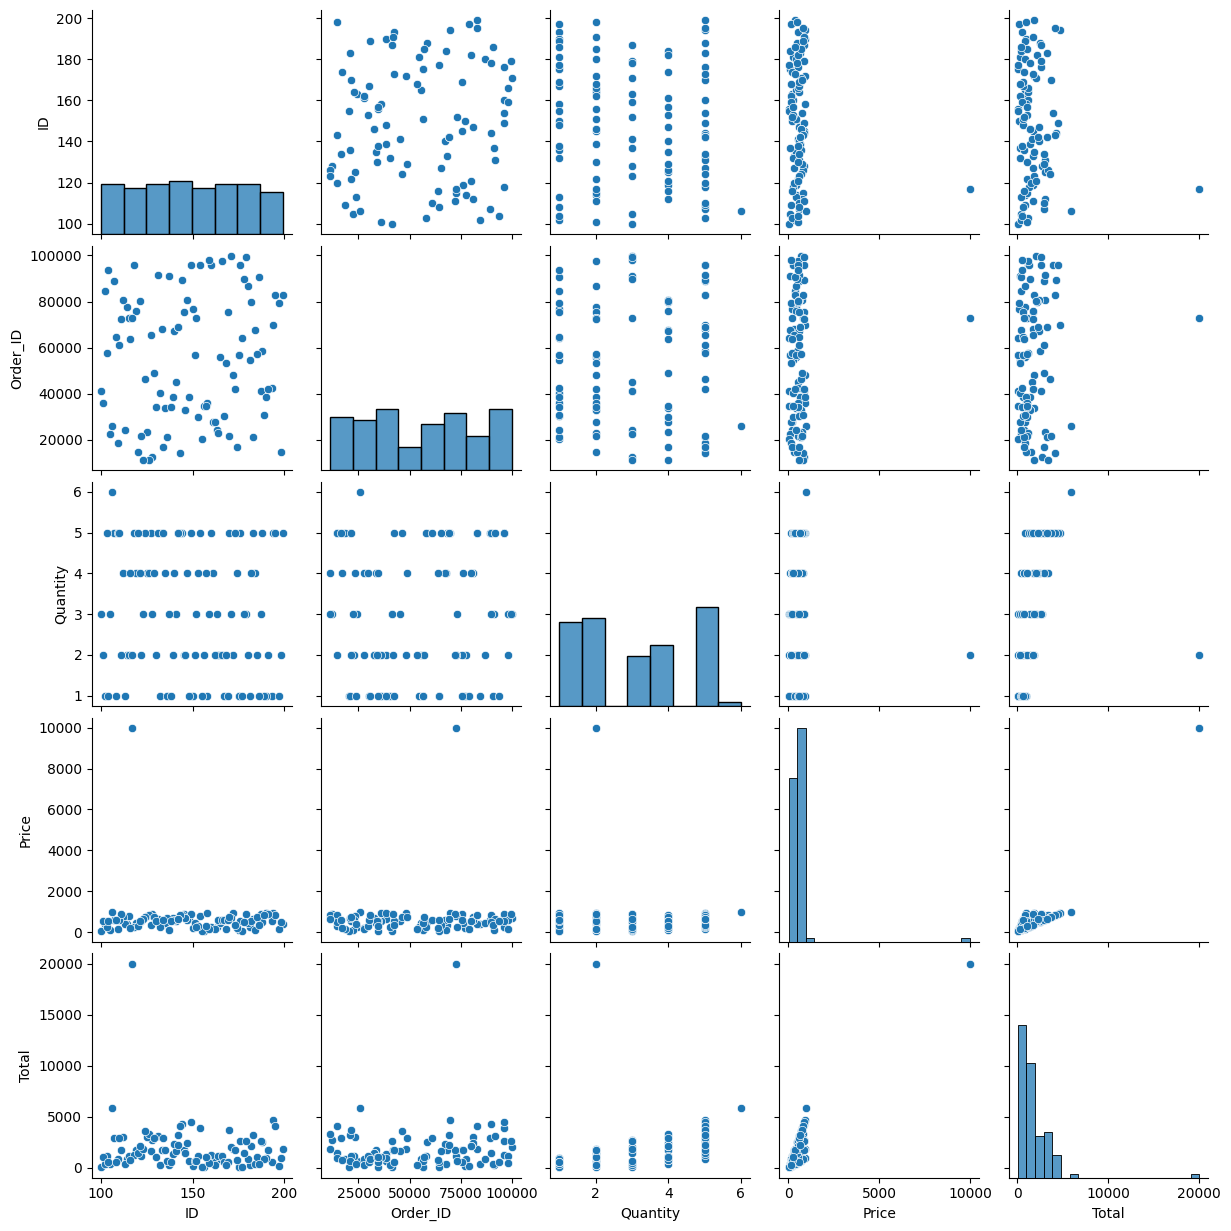

In [176]:
sns.pairplot(data=ecommerce_sales_data)

#### Insights
- Price and Total show a strong positive relationship

<Axes: >

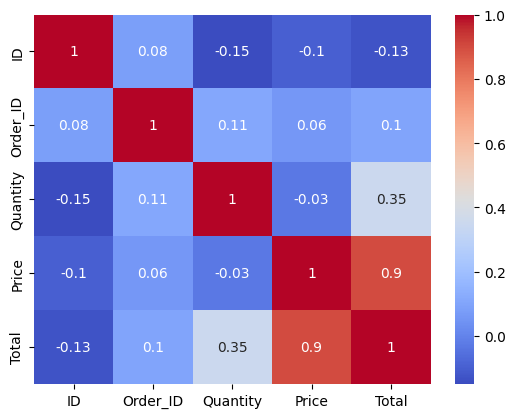

In [177]:
sns.heatmap(
    data=ecommerce_sales_data.select_dtypes(include="number")
    .corr(method="pearson")
    .round(2),
    annot=True,
    cmap="coolwarm",
)

#### Insights
- Price and Total have strong positive correlation 
- Quanity and Total show weak correlation

---

# Advance Data Visualization in Presentaion Point of View

## 1. Revenue Trend Over Time

In [178]:
delivered_order = ecommerce_sales_data[ecommerce_sales_data.Status == "Delivered"]


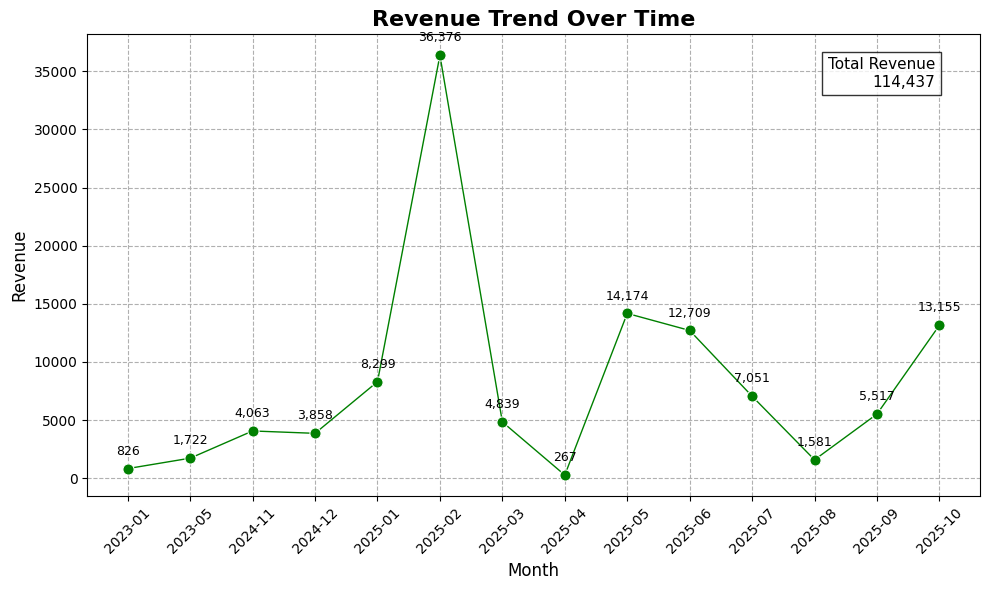

In [179]:
monthly_revenue = (
    delivered_order.groupby(delivered_order["Order_Date"].dt.to_period("M"))["Total"]
    .sum()
    .reset_index()
)
monthly_revenue["Order_Date"] = monthly_revenue["Order_Date"].astype(str)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x="Order_Date",
    y="Total",
    color="green",
    linewidth=1,
    marker="o",
    markersize=8,
)

plt.title("Revenue Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)


plt.grid(True, linestyle="--", alpha=1)

for i, value in enumerate(monthly_revenue["Total"]):
    plt.annotate(
        f"{value:,.0f}",
        (i, value),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

total_revenue = monthly_revenue["Total"].sum()

plt.text(
    0.95,
    0.95,
    f"Total Revenue\n{total_revenue:,.0f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()

#### Insights
* Revenue fluctuated over time
* February 2025 recorded peak revenue
* Sharp decline followed after peak
* Revenue recovered in later months

## 1.1 Category wise Revenue - Feb 2025

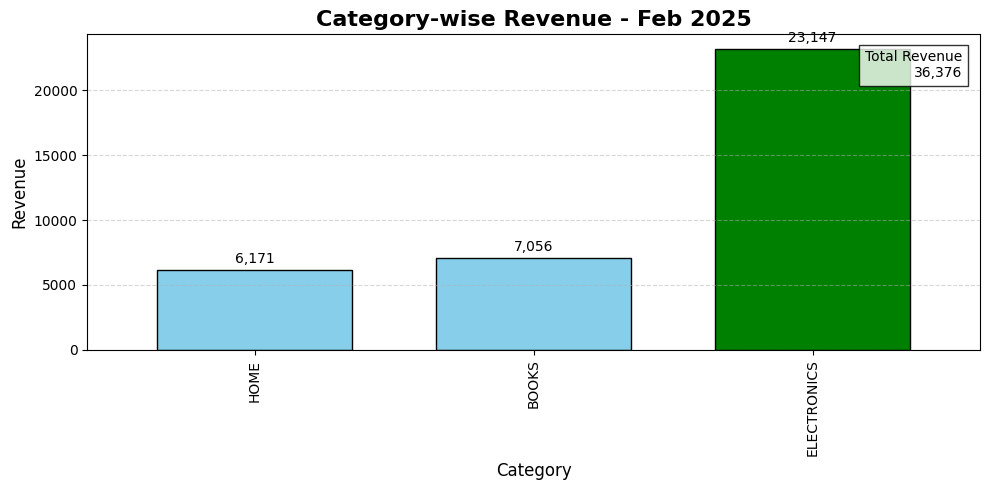

In [180]:
delivered_order["Order_Date"] = pd.to_datetime(delivered_order["Order_Date"])

feb_data = delivered_order[
    delivered_order["Order_Date"].dt.strftime("%Y-%m") == "2025-02"
]

category_sales = (
    feb_data.groupby("Category")["Total"].sum().sort_values(ascending=False)
)

top_category = category_sales.idxmax()

colors = [
    "green" if cat == top_category else "skyblue"
    for cat in category_sales.sort_values().index
]

plt.figure(figsize=(10, 5))

ax = category_sales.sort_values().plot(
    kind="bar", color=colors, edgecolor="black", width=0.7
)

plt.title("Category-wise Revenue - Feb 2025", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue", fontsize=12)


plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

total_revenue = category_sales.sum()

plt.text(
    0.98,
    0.95,
    f"Total Revenue\n{total_revenue:,.0f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()

#### Insights
* Electronics generated highest revenue
* Sales mainly concentrated in Electronics
* Books and Home showed moderate performance

## 2. Category Performance by Revenue


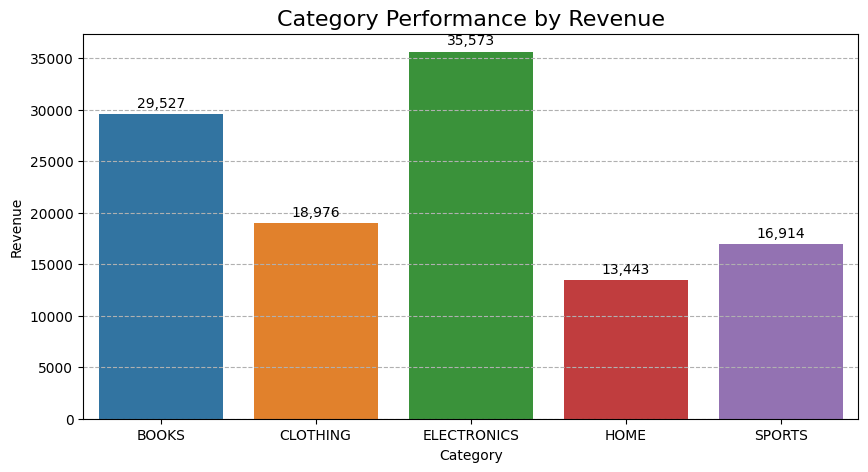

In [181]:
category_revenue = delivered_order.groupby("Category")["Total"].sum().reset_index()


plt.figure(figsize=(10, 5))


ax = sns.barplot(
    data=category_revenue,
    x="Category",
    y="Total",
    hue="Category",
)

plt.title("Category Performance by Revenue", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Revenue")


plt.grid(axis="y", linestyle="--", alpha=1)

for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.show()

#### Insights
* Electronics remained top category
* Books performed strongly
* Home generated lowest revenue
* Revenue spread across categories

## 3. Top Products by Revenue


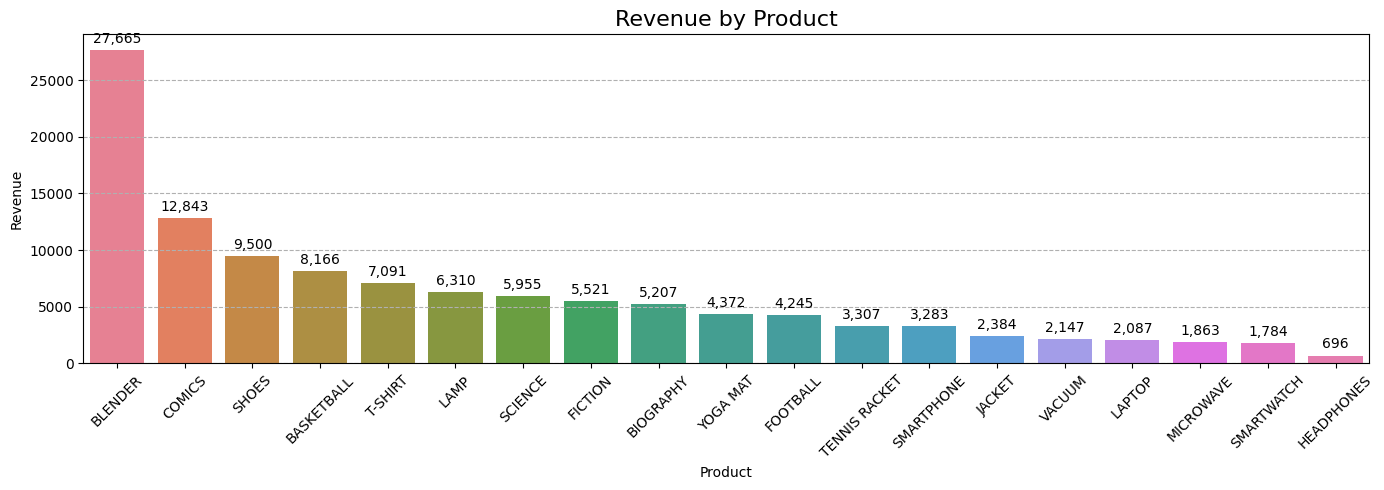

In [182]:
product_revenue  = (delivered_order.groupby("Product")["Total"].sum().reset_index().sort_values(by="Total", ascending=False))

plt.figure(figsize=(14, 5))

ax = sns.barplot(
    data=product_revenue,
    x="Product",
    y="Total",
    hue="Product"
)

plt.title("Revenue by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=1)

for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

#### Insights
* Blender was the top-performing product
* Top products contributed major revenue
* Some products showed lower sales potential

## 4. Payment Method Usage


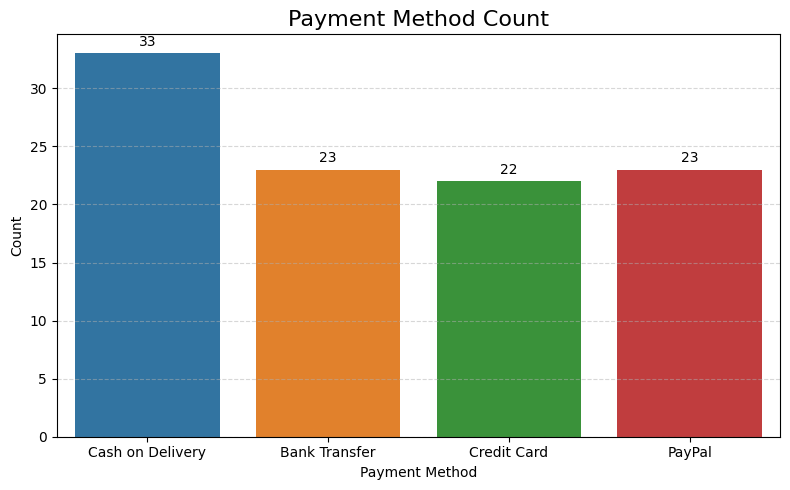

In [183]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=ecommerce_sales_data,
    x="Payment_Method",
    hue="Payment_Method"
)

plt.title("Payment Method Count", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Count")


plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

#### Insights
* Cash on Delivery was most preferred
* Digital payments showed balanced usage
* Customers used multiple payment options

## 5. Payment Method vs Order Status


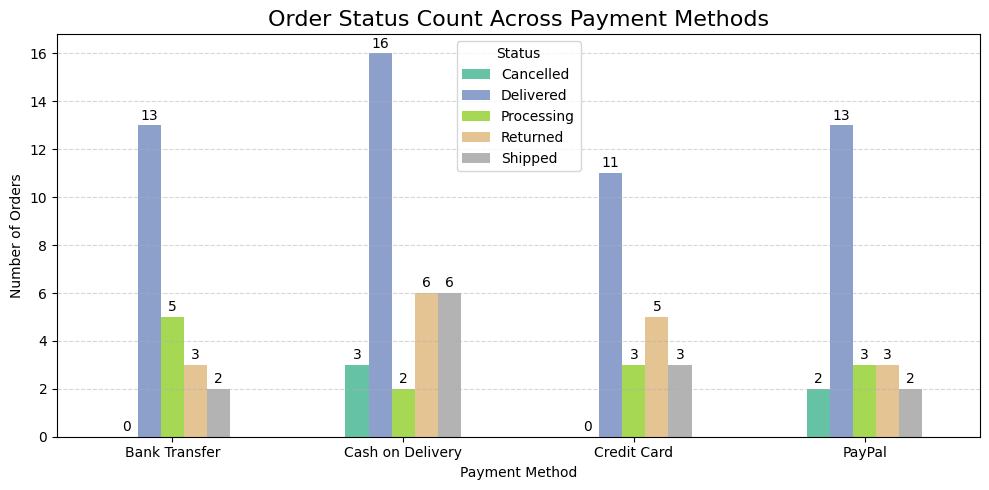

In [184]:
count_table = pd.crosstab(
    ecommerce_sales_data["Payment_Method"], ecommerce_sales_data["Status"]
)


ax = count_table.plot(
    kind="bar", stacked=False, figsize=(10, 5), width=0.5, colormap="Set2" 
)

plt.title("Order Status Count Across Payment Methods", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=0)




for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.tight_layout()
plt.show()

#### Insights
* Delivered orders were highest
* Returns and processing orders were noticeable
* Fulfillment improvement may reduce delays

## 6. Revenue Loss Due to Cancellation


### 6.1 Revenue by Order Status

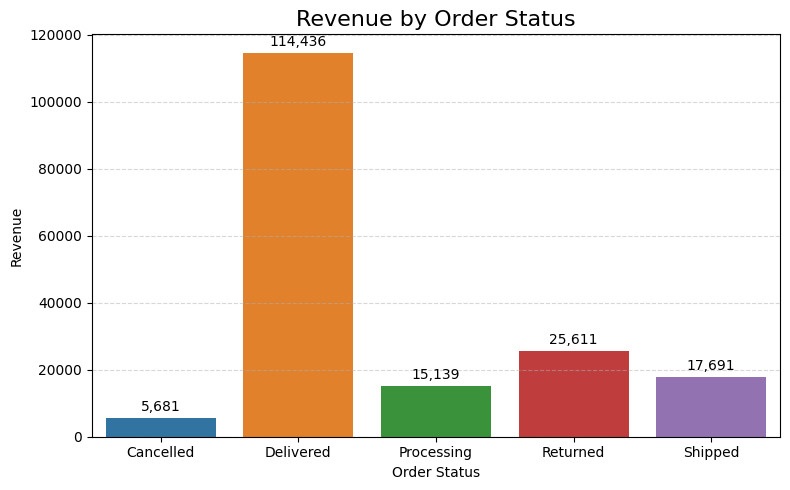

In [185]:
status_revenue = ecommerce_sales_data.groupby("Status")["Total"].sum().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=status_revenue,
    x="Status",
    y="Total",
    hue="Status"
)

plt.title("Revenue by Order Status", fontsize=16)
plt.xlabel("Order Status")
plt.ylabel("Revenue")


plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)
    
    

plt.tight_layout()
plt.show()

### 6.2 Order Count by Status

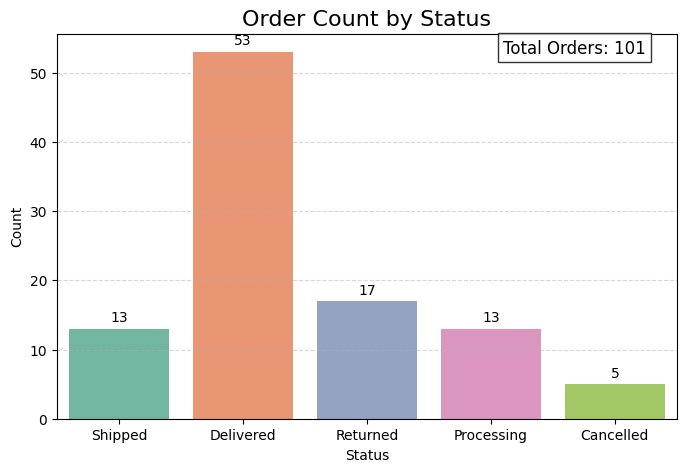

In [186]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=ecommerce_sales_data, x="Status", hue="Status", palette="Set2", legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

total_orders = len(ecommerce_sales_data)

plt.text(
    0.95,
    0.95,
    f"Total Orders: {total_orders:,}",
    transform=ax.transAxes,
    ha="right",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8),
)

plt.title("Order Count by Status", fontsize=16)
plt.xlabel("Status")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

#### Insights
* Delivered orders generated highest revenue
* Returns affected business performance
* Low cancellations reduced revenue loss
* Better fulfillment can improve satisfaction

---

# The End